# Initial EDA on event dataset (events_combined.csv)

In [2]:
import pandas as pd
import duckdb
# import data from csv-file
df = pd.read_csv("../data/output/events_combined.csv")

df

,event_id,name,url,image_url,date,time,status,segment,genre,subgenre,...,venue_city,venue_address,venue_lat,venue_lon,day_of_week,month_name,month_num,year,hour,source
0,Z698xZq2Z1kaPZUZN,Christopher Cross,https://www.ticketmaster.se/event/christopher-...,https://s1.ticketm.net/dam/e/ebc/f9ec9170-cedf...,2026-04-20,19:00,onsale,Music,Other,Other,...,Stockholm,Djurgårdsslätten 43-45,59.32457,18.09969,Monday,April,4,2026,19.0,ticketmaster
1,Z698xZq2Z16vAgbJjd,"Matt Rife: Stay Golden World Tour, Platinum Ti...",https://www.ticketmaster.se/event/matt-rife-st...,https://s1.ticketm.net/dam/a/0c9/ca006906-7ad8...,2026-04-20,19:30,onsale,Arts & Theatre,Comedy,Comedy,...,Stockholm,Globentorget 2,59.29416,18.08081,Monday,April,4,2026,19.0,ticketmaster
2,Z698xZq2Z1kx9Fbb_,Svartklubben - Mat & Musik i Mörker,https://www.ticketmaster.se/event/svartklubben...,https://s1.ticketm.net/dam/a/841/1c1b2a57-616a...,2026-04-21,18:00,onsale,Arts & Theatre,Theatre,Miscellaneous,...,Stockholm,Södermannagatan 27,59.31209,18.08133,Tuesday,April,4,2026,18.0,ticketmaster
3,Z698xZq2Z16vjZPaOs,Rhythm of the Dance,https://www.ticketmaster.se/event/rhythm-of-th...,https://s1.ticketm.net/dam/e/0ee/03d1602c-7a6a...,2026-04-21,19:00,onsale,Arts & Theatre,Dance,Dance,...,Stockholm,Djurgårdsslätten 43-45,59.32457,18.09969,Tuesday,April,4,2026,19.0,ticketmaster
4,Z698xZq2Z1kqkAAJo,Stödkonsert för Ukraina: Borys Ljatosjynsky,https://www.ticketmaster.se/event/stodkonsert-...,https://s1.ticketm.net/dam/a/c23/43c3d863-3ce7...,2026-04-21,19:00,onsale,Arts & Theatre,Theatre,Miscellaneous,...,Stockholm,Helgalunden 9,59.30982,18.07379,Tuesday,April,4,2026,19.0,ticketmaster
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1185,NaN,Nubiyan Twist,https://www.fasching.se/nubiyan-twist-2026-11-...,https://www.fasching.se/wp-content/uploads/202...,2026-11-14,21:00,onsale,Nightlife,Jazz/Klubb,NaN,...,Stockholm,"Kungsgatan 63, Stockholm",59.33340,18.05570,Saturday,November,11,2026,21.0,fasching
1186,NaN,NUET x INNELLEA,https://berns.se/calendar/nuet-x-innellea/,https://berns.se/wp-content/uploads/2026/03/IN...,2026-04-24,NaN,onsale,Nightlife,Klubb/Konsert,NaN,...,Stockholm,"Berzelii Park, Stockholm",59.33230,18.07340,Friday,April,4,2026,NaN,berns
1187,NaN,Eric Gadd x Blacknuss,https://berns.se/calendar/eric-gadd-x-blacknuss/,https://berns.se/wp-content/uploads/2026/02/ga...,2026-04-25,NaN,onsale,Nightlife,Klubb/Konsert,NaN,...,Stockholm,"Berzelii Park, Stockholm",59.33230,18.07340,Saturday,April,4,2026,NaN,berns
1188,NaN,BULLERBYN x VALBORG,https://berns.se/calendar/bullerbyn-x-valborg-2/,https://berns.se/wp-content/uploads/2026/03/BB...,2026-04-30,NaN,onsale,Nightlife,Klubb/Konsert,NaN,...,Stockholm,"Berzelii Park, Stockholm",59.33230,18.07340,Thursday,April,4,2026,NaN,berns


In [3]:
df.head()

,event_id,name,url,image_url,date,time,status,segment,genre,subgenre,...,venue_city,venue_address,venue_lat,venue_lon,day_of_week,month_name,month_num,year,hour,source
0,Z698xZq2Z1kaPZUZN,Christopher Cross,https://www.ticketmaster.se/event/christopher-...,https://s1.ticketm.net/dam/e/ebc/f9ec9170-cedf...,2026-04-20,19:00,onsale,Music,Other,Other,...,Stockholm,Djurgårdsslätten 43-45,59.32457,18.09969,Monday,April,4,2026,19.0,ticketmaster
1,Z698xZq2Z16vAgbJjd,"Matt Rife: Stay Golden World Tour, Platinum Ti...",https://www.ticketmaster.se/event/matt-rife-st...,https://s1.ticketm.net/dam/a/0c9/ca006906-7ad8...,2026-04-20,19:30,onsale,Arts & Theatre,Comedy,Comedy,...,Stockholm,Globentorget 2,59.29416,18.08081,Monday,April,4,2026,19.0,ticketmaster
2,Z698xZq2Z1kx9Fbb_,Svartklubben - Mat & Musik i Mörker,https://www.ticketmaster.se/event/svartklubben...,https://s1.ticketm.net/dam/a/841/1c1b2a57-616a...,2026-04-21,18:00,onsale,Arts & Theatre,Theatre,Miscellaneous,...,Stockholm,Södermannagatan 27,59.31209,18.08133,Tuesday,April,4,2026,18.0,ticketmaster
3,Z698xZq2Z16vjZPaOs,Rhythm of the Dance,https://www.ticketmaster.se/event/rhythm-of-th...,https://s1.ticketm.net/dam/e/0ee/03d1602c-7a6a...,2026-04-21,19:00,onsale,Arts & Theatre,Dance,Dance,...,Stockholm,Djurgårdsslätten 43-45,59.32457,18.09969,Tuesday,April,4,2026,19.0,ticketmaster
4,Z698xZq2Z1kqkAAJo,Stödkonsert för Ukraina: Borys Ljatosjynsky,https://www.ticketmaster.se/event/stodkonsert-...,https://s1.ticketm.net/dam/a/c23/43c3d863-3ce7...,2026-04-21,19:00,onsale,Arts & Theatre,Theatre,Miscellaneous,...,Stockholm,Helgalunden 9,59.30982,18.07379,Tuesday,April,4,2026,19.0,ticketmaster


In [4]:
# check RangeIndex & non-null
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1190 entries, 0 to 1189
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   event_id       1105 non-null   str    
 1   name           1190 non-null   str    
 2   url            1190 non-null   str    
 3   image_url      1190 non-null   str    
 4   date           1190 non-null   str    
 5   time           618 non-null    str    
 6   status         1190 non-null   str    
 7   segment        1190 non-null   str    
 8   genre          998 non-null    str    
 9   subgenre       913 non-null    str    
 10  venue_name     1173 non-null   str    
 11  venue_city     1170 non-null   str    
 12  venue_address  1186 non-null   str    
 13  venue_lat      1190 non-null   float64
 14  venue_lon      1190 non-null   float64
 15  day_of_week    1190 non-null   str    
 16  month_name     1190 non-null   str    
 17  month_num      1190 non-null   int64  
 18  year           1190

In [5]:
df.columns

Index(['event_id', 'name', 'url', 'image_url', 'date', 'time', 'status',
       'segment', 'genre', 'subgenre', 'venue_name', 'venue_city',
       'venue_address', 'venue_lat', 'venue_lon', 'day_of_week', 'month_name',
       'month_num', 'year', 'hour', 'source'],
      dtype='str')

In [6]:
# descriptive statistics of summative statistics (only numerical columns)
df.describe().T

,count,mean,std,min,25%,50%,75%,max
venue_lat,1190.0,59.351982,0.135948,58.957408,59.313946,59.32457,59.334200,59.993330
venue_lon,1190.0,18.104455,0.176580,17.398113,18.055700,18.07384,18.096259,18.920662
month_num,1190.0,6.536975,2.653825,1.000000,5.000000,5.00000,9.000000,12.000000
year,1190.0,2026.031092,0.173641,2026.000000,2026.000000,2026.00000,2026.000000,2027.000000
hour,618.0,18.095469,2.970784,0.000000,18.000000,19.00000,20.000000,23.000000


In [7]:
# check number of rows and columns
print(f"Rows: {df.shape[0]}, Cols: {df.shape[1]}")

Rows: 1190, Cols: 21


In [8]:
df["segment"].value_counts()

segment
Arts & Theatre    527
Music             424
Miscellaneous     125
Nightlife          85
Sports             29
Name: count, dtype: int64

In [9]:
df["genre"].value_counts()

genre
Jazz & Blues               231
Theatre                    183
Comedy                      82
Jazz/Klubb                  81
Rock                        54
Film                        54
Culture & Arts              52
Dance                       51
Other                       37
Food & Drink                26
Games & Championships       25
Hip-Hop/Rap                 19
Family                      15
Conventions & Fairs         14
Magic & Illusion            10
Dance/Electronic             9
Classical                    7
Spectacular                  7
Folk                         6
Alternative                  4
Klubb/Konsert                4
Fairs & Festivals            3
World                        3
Miscellaneous                3
Latin                        3
Children's Theatre           3
Blues                        2
Metal                        2
Soccer                       2
Martial Arts                 1
Reggae                       1
Pop                          1
R&

In [10]:
# how many different events do we have?
duckdb.sql("""--sql
SELECT
DISTINCT(name)
FROM df
""")

┌──────────────────────────────────────────────────────────────────────┐
│                                 name                                 │
│                               varchar                                │
├──────────────────────────────────────────────────────────────────────┤
│ Scott Bradlee’s Postmodern Jukebox - The Future Is Vintage Tour 2026 │
│ Bongos Bingo Sverigepremiär                                          │
│ Kärleksbrev – En teaterföreställning om kärlek                       │
│ Staffan Hellstrand med vänner 70år                                   │
│ Alesso                                                               │
│ Original Enigma Voices                                               │
│ J. Cole: The Fall-Off Tour, Platinum Tickets                         │
│ Noah Kahan: The Great Divide World Tour, Platinum Tickets            │
│ NANNE GRÖNVALLS JUBILEUMSTURNÈ - HÄR ÄR JAG                          │
│ Nine Soles – Nine Days                           

In [36]:
# how many, and which events is there a specific date
# using Window functions OVER() to aggregate over the full result set
duckdb.sql("""
SELECT
    name,
    venue_name,
    date,
    COUNT(*) OVER(PARTITION BY venue_name) AS number_events
FROM df
WHERE date = '2026-05-20'
    ORDER BY number_events DESC
""").df()


,name,venue_name,date,number_events
0,Tori Amos,Cirkus,2026-05-20,2
1,Tori Amos - Live at Cirkus,Cirkus,2026-05-20,2
2,Gunilla Törnfeldt,Fasching,2026-05-20,1
3,16 Horsepower – Live at Fållan,Fållan,2026-05-20,1


In [19]:
# which days has most events?
duckdb.sql("""
SELECT
    date,
    COUNT(*) AS num_events
    FROM df
    GROUP BY date
    ORDER BY num_events DESC
    LIMIT 5
""")

┌────────────┬────────────┐
│    date    │ num_events │
│  varchar   │   int64    │
├────────────┼────────────┤
│ 2026-04-25 │         51 │
│ 2026-04-20 │         42 │
│ 2026-05-09 │         33 │
│ 2026-04-24 │         28 │
│ 2026-04-30 │         26 │
└────────────┴────────────┘

In [20]:
# which event has the most nr of shows?
duckdb.sql("""
SELECT
    name,
    COUNT(*) AS num_shows
    FROM df
    GROUP BY name
    ORDER BY num_shows DESC
    LIMIT 5
""")

┌────────────────────────────────────────┬───────────┐
│                  name                  │ num_shows │
│                varchar                 │   int64   │
├────────────────────────────────────────┼───────────┤
│ MAMMA MIA! THE PARTY                   │        67 │
│ Torka aldrig tårar utan handskar       │        39 │
│ Svartklubben - Mat & Musik i Mörker    │        35 │
│ & Julia                                │        23 │
│ Fredrik ”Benke” Rydman – Romeo & Julia │        14 │
└────────────────────────────────────────┴───────────┘

In [27]:
# which venue has most events booked this week? (week 17)
duckdb.sql("""
SELECT
    venue_name AS venue,
    COUNT(*) AS total_events
FROM df
WHERE date BETWEEN '2026-04-20' AND '2026-04-26'
GROUP BY venue_name
ORDER BY total_events DESC
LIMIT 5
""").df()

,venue,total_events
0,Fasching,8
1,Cirkus,7
2,Allhelgonakyrkan,5
3,Rival,5
4,Svartklubben,5


In [54]:
# Which events has missing id's?
duckdb.sql("""
    SELECT source,
           COUNT(*)
               FILTER (WHERE event_id IS NULL) AS null_ids
FROM df
    GROUP BY source""").df()

,source,null_ids
0,berns,4
1,fasching,81
2,visitstockholm,0
3,ticketmaster,0


## Visualizations

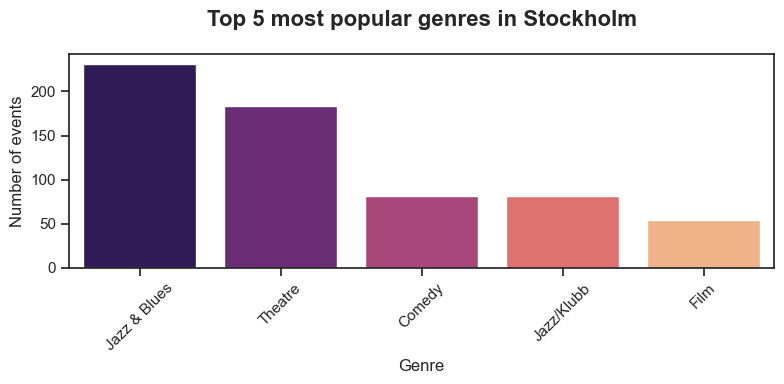

In [28]:
import seaborn as sns
import matplotlib.pyplot as plt

""" --- 5 Most Popular Genre --- """

# 1. Calculation using DuckDB
result_top_genres = duckdb.sql("""
    SELECT
        genre,
        COUNT(*) AS event_count
    FROM df
    WHERE genre IS NOT NULL
    GROUP BY genre
    ORDER BY event_count DESC
    LIMIT 5
""")

# 2. Convert result to DataFrame
top_genres = result_top_genres.df()

# 3. Choose a theme
sns.set_theme(style="ticks")

# 3. Create graph
plt.figure(figsize=(8, 4))
ax = sns.barplot(
    data=top_genres,
    x="genre",
    y="event_count",
    palette="magma", # colorpalette
    hue="genre",     # Gives every row a unique color
    legend=False
)

# 4. Data Storytelling: Clear titles and labels
plt.title("Top 5 most popular genres in Stockholm", fontsize=16, fontweight='bold', pad=20)
plt.xlabel("Genre", fontsize=12)
plt.ylabel("Number of events", fontsize=12)

# Rotate text on x-axis
plt.xticks(rotation=45)

# 5. Save and plot
plt.tight_layout()
plt.savefig("data_images/top_genres.png", dpi=300)
plt.show()

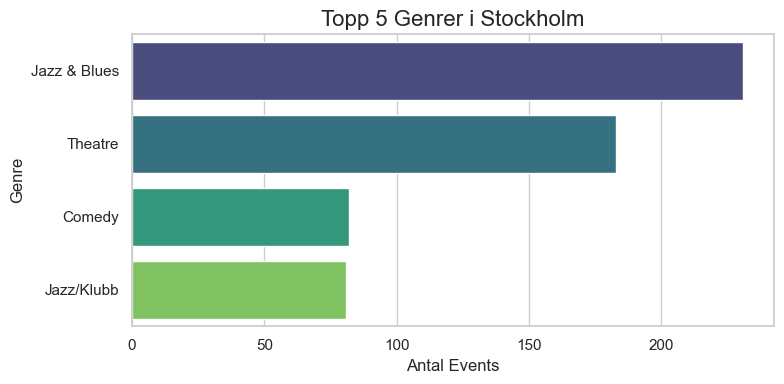

In [29]:
""" --- Number Of Events Per Genre --- """

result = duckdb.sql("""
SELECT
    genre,
    COUNT(*) AS num_events
    FROM df
    GROUP BY genre
    ORDER BY num_events DESC
    LIMIT 5
""")

plot_df = result.df()

sns.set_theme(style="whitegrid")

plt.figure(figsize=(8, 4))
ax = sns.barplot(
    data=plot_df,
    x="num_events",
    y="genre",
    hue="genre",
    palette="viridis",
    legend=False
)

plt.title("Topp 5 Genrer i Stockholm", fontsize=16)
plt.xlabel("Antal Events", fontsize=12)
plt.ylabel("Genre", fontsize=12)

plt.tight_layout()
plt.savefig("data_images/events_per_genre.png", dpi=300)
plt.show()

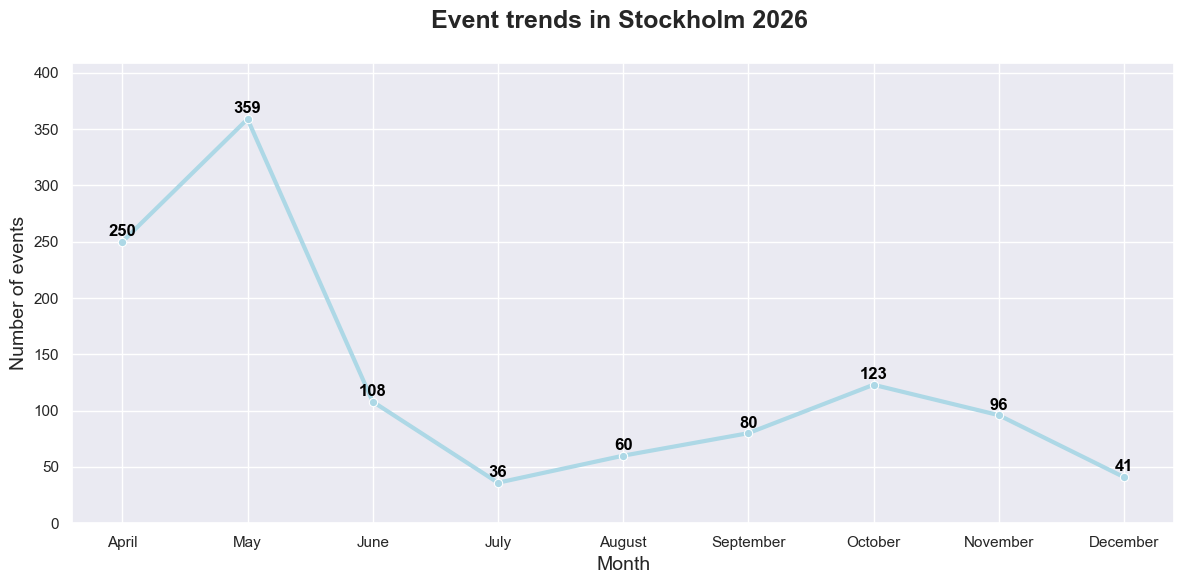

In [45]:
""" --- Number Of Events Over Time In 2026 --- """

result_monthly = duckdb.sql("""
    SELECT
        month_num,
        month_name,
        COUNT(*) AS event_count
    FROM df
    WHERE year = 2026
    GROUP BY month_num, month_name
    ORDER BY month_num
""")

monthly_data = result_monthly.df()

sns.set_theme(style="darkgrid")
plt.figure(figsize=(12, 6))

# Create linechart
ax = sns.lineplot(
    data=monthly_data,
    x='month_name',
    y='event_count',
    marker='o',
    linewidth=3,
    color='lightblue'
)

# Add values (number of events) above marks
for x, y in zip(monthly_data['month_name'], monthly_data['event_count']):
    plt.text(x, y + 5, str(y), color='black', ha="center", fontweight='bold')


plt.title('Event trends in Stockholm 2026 ', fontsize=18, fontweight='bold', pad=25)
plt.xlabel('Month', fontsize=14)
plt.ylabel('Number of events', fontsize=14)
plt.ylim(0, monthly_data['event_count'].max() + 50)


plt.tight_layout()
plt.savefig("data_images/event_trends_2026.png", dpi=300)
plt.show()

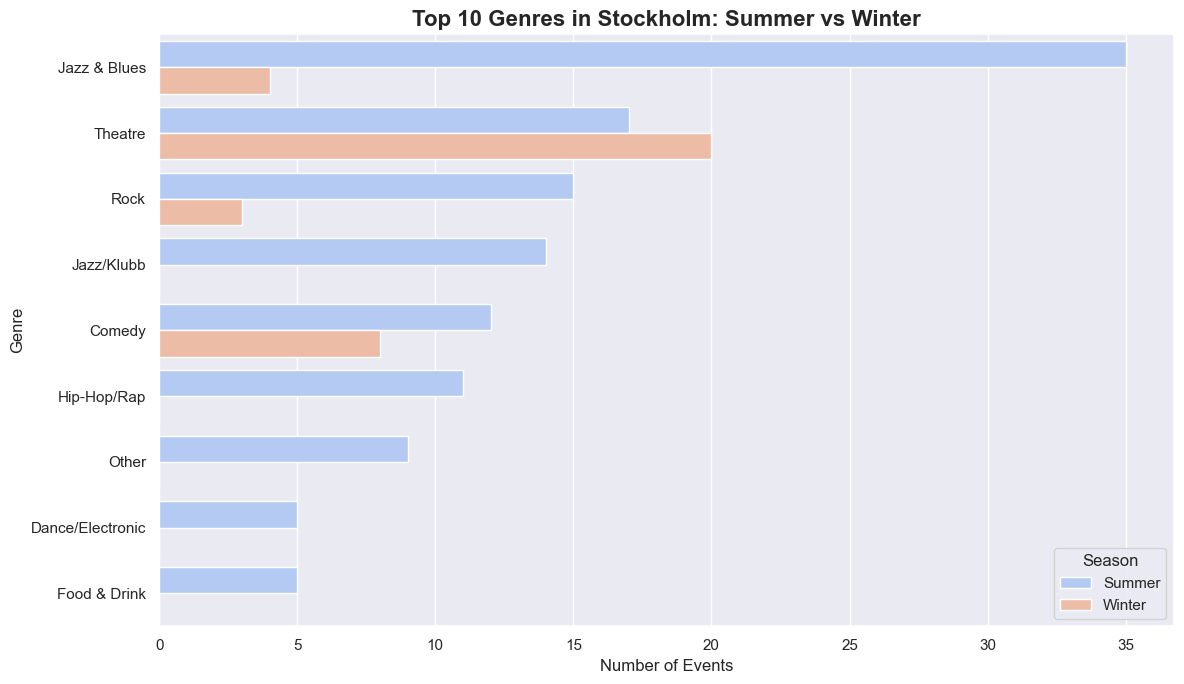

In [52]:
""" --- Genre Dominance: Summer vs Winter (Stockholm) --- """

query_genres = """
SELECT
    genre,
    COUNT(*) FILTER (WHERE month_num IN (6, 7, 8)) AS Summer,
    COUNT(*) FILTER (WHERE month_num IN (12, 1, 2)) AS Winter
FROM df
WHERE venue_city = 'Stockholm'
GROUP BY genre
HAVING Summer > 0 OR Winter > 0
ORDER BY Summer DESC
LIMIT 10
"""

genre_data = duckdb.sql(query_genres).df()

# Prepare data for Seaborn (melt it)
genre_melted = genre_data.melt(id_vars='genre', var_name='Season', value_name='Count')

plt.figure(figsize=(12, 7))
sns.barplot(data=genre_melted, x='Count', y='genre', hue='Season', palette='coolwarm')

plt.title('Top 10 Genres in Stockholm: Summer vs Winter', fontsize=16, fontweight='bold')
plt.xlabel('Number of Events')
plt.ylabel('Genre')
plt.legend(title='Season')
plt.tight_layout()
plt.show()

## EDA on museums data (Stockholm_museum_full.csv)

In [37]:
m_df = pd.read_csv("../api/Stockholm_museum_full.csv")

m_df.head()

,event_id,name,url,venue_name,venue_address,venue_city,venue_lat,venue_lon,rating,num_reviews,...,year,month_name,is_free,popularity_score,popularity_index,adult_price_sek,child_price_sek,free_age_range,student_price_sek,senior_price_sek
0,ChIJrymDbVSdX0YRQTLBtPGa8M8,Vasamuseet,https://www.vasamuseet.se/,Vasamuseet,"Galärvarvsvägen 14, 115 21 Stockholm, Sverige",Stockholm,59.328023,18.091396,4.8,66926,...,2026,All Year,False,1241.8,100.0,240,0,0–18,prisinformation saknas,prisinformation saknas
1,ChIJN5Ta_qqCX0YRMYVG1s-2NSw,Skansen,https://www.skansen.se/,Skansen,"Djurgårdsslätten 49-51, 115 21 Stockholm, Sverige",Stockholm,59.326323,18.105858,4.5,34496,...,2026,All Year,False,835.8,62.9,329,120,0–15,279.0,279.0
2,ChIJBf9B06qCX0YRR46XNXjwFUo,ABBA The Museum,https://www.abbathemuseum.com/,ABBA The Museum,"Djurgårdsvägen 68, 115 21 Stockholm, Sverige",Stockholm,59.325091,18.096781,4.5,20093,...,2026,All Year,False,637.9,44.8,329,120,0–6,279.0,279.0
3,ChIJhaN0M_l3X0YRpOq8uRb_RcA,Fotografiska Stockholm,https://stockholm.fotografiska.com/,Fotografiska Stockholm,"Stadsgårdshamnen 22, 116 45 Stockholm, Sverige",Stockholm,59.317962,18.084827,4.4,19504,...,2026,All Year,False,614.5,42.6,195,0,0–16,165.0,165.0
4,ChIJxagZg1OdX0YRGKnPhRyci9c,Nordiska museet,https://www.nordiskamuseet.se/,Nordiska museet,"Djurgårdsvägen 6-16, 115 93 Stockholm, Sverige",Stockholm,59.329008,18.094268,4.3,11098,...,2026,All Year,False,453.0,27.9,160,0,3–18,130.0,130.0


In [38]:
m_df.shape

(20, 25)

In [39]:
m_df.columns

Index(['event_id', 'name', 'url', 'venue_name', 'venue_address', 'venue_city',
       'venue_lat', 'venue_lon', 'rating', 'num_reviews', 'opening_hours',
       'status', 'segment', 'genre', 'subgenre', 'year', 'month_name',
       'is_free', 'popularity_score', 'popularity_index', 'adult_price_sek',
       'child_price_sek', 'free_age_range', 'student_price_sek',
       'senior_price_sek'],
      dtype='str')

In [40]:
m_df["rating"].value_counts()

rating
4.5    6
4.4    4
4.3    4
4.8    2
4.6    2
4.1    1
4.2    1
Name: count, dtype: int64

In [41]:
m_df["is_free"].value_counts()


is_free
False    13
True      7
Name: count, dtype: int64

In [42]:
m_df.describe().T

,count,mean,std,min,25%,50%,75%,max
venue_lat,20.0,59.331897,0.011870,59.317962,59.326254,59.328773,59.333457,59.368975
venue_lon,20.0,18.082953,0.015764,18.053878,18.070844,18.083012,18.092389,18.118803
rating,20.0,4.445000,0.176143,4.100000,4.300000,4.450000,4.500000,4.800000
num_reviews,20.0,11320.800000,15422.255906,1131.000000,2706.750000,7238.500000,9715.750000,66926.000000
year,20.0,2026.000000,0.000000,2026.000000,2026.000000,2026.000000,2026.000000,2026.000000
popularity_score,20.0,408.575000,264.043774,148.000000,227.425000,370.450000,428.625000,1241.800000
popularity_index,20.0,23.825000,24.142186,0.000000,7.250000,20.350000,25.650000,100.000000
adult_price_sek,20.0,185.750000,70.409984,0.000000,160.000000,170.000000,209.000000,329.000000
child_price_sek,20.0,40.950000,66.448615,0.000000,0.000000,0.000000,111.250000,195.000000


In [62]:
# What are the "free age range" on each museum?
duckdb.sql("""
SELECT name,
       free_age_range,
       child_price_sek FROM m_df""").df()

,name,free_age_range,child_price_sek
0,Vasamuseet,0–18,0
1,Skansen,0–15,120
2,ABBA The Museum,0–6,120
3,Fotografiska Stockholm,0–16,0
4,Nordiska museet,3–18,0
5,Naturhistoriska riksmuseet och Cosmonova,0–17,0
6,Tekniska museet,0–6,0
7,Nationalmuseum,0–19,0
8,Nobelprismuseet,0–18,0
9,Historiska museet,0–18,0


## Visualization

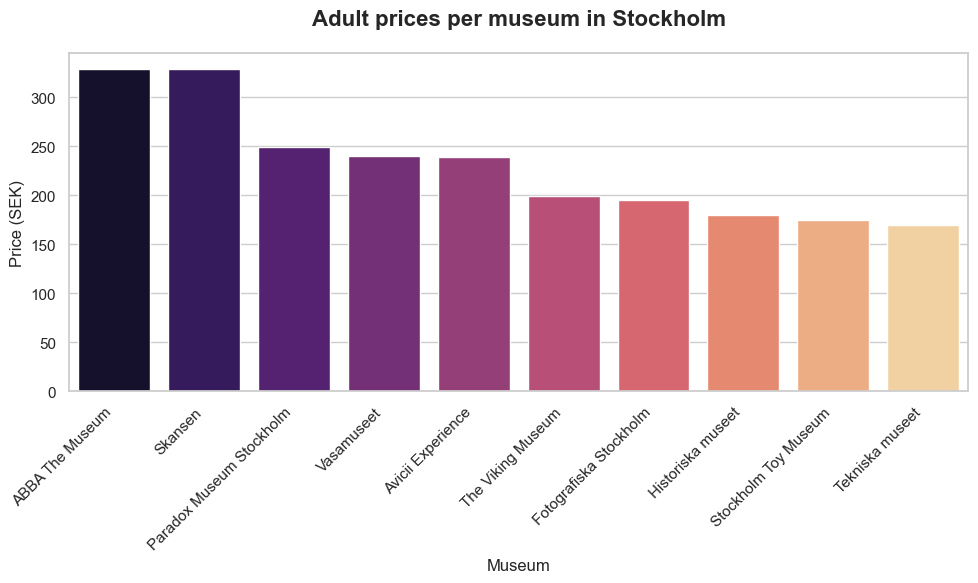

In [61]:
""" --- Top 10 most expensive Museum in Stockholm (for adults) --- """

# 1. Query
adult_prices = duckdb.sql("""
    SELECT
        name AS Museum,
        adult_price_sek
    FROM m_df
    ORDER BY adult_price_sek DESC
    LIMIT 10
""").df()

# 2. Theme
sns.set_theme(style="whitegrid")

# 3. Create graph
plt.figure(figsize=(10, 6))
ax = sns.barplot(
    data=adult_prices,
    x="Museum",
    y="adult_price_sek",
    palette="magma",
    hue="Museum",
    legend=False
)

# 4. Labels
plt.title("Adult prices per museum in Stockholm", fontsize=16, fontweight="bold", pad=20)
plt.xlabel("Museum", fontsize=12)
plt.ylabel("Price (SEK)", fontsize=12)
plt.xticks(rotation=45, ha="right")

# 5. Save and plot
plt.tight_layout()
# plt.savefig("data_images/adult_prices.png", dpi=300)
plt.show()

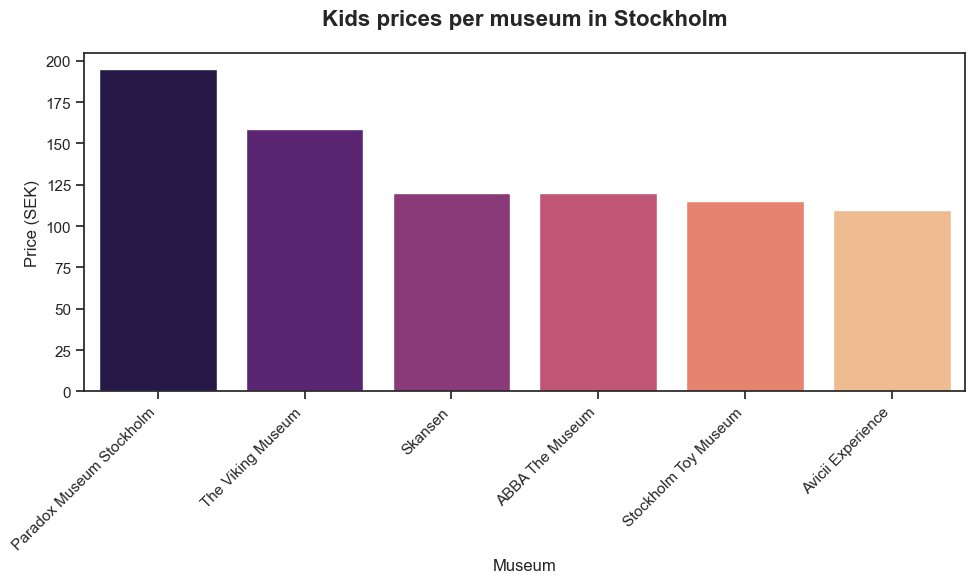

In [65]:
""" --- Child prices at Museum without free entrees --- """

# 1. Query — exclude free museums (price = 0) so they don't clutter the chart
child_prices = duckdb.sql("""
    SELECT
        name AS Museum,
        child_price_sek
    FROM m_df
    WHERE child_price_sek > 0
    ORDER BY child_price_sek DESC
""").df()

# 2. Theme
sns.set_theme(style="ticks")

# 3. Create graph
plt.figure(figsize=(10, 6))
ax = sns.barplot(
    data=child_prices,
    x="Museum",
    y="child_price_sek",
    palette="magma",
    hue="Museum",
    legend=False
)

# 4. Labels
plt.title("Kids prices per museum in Stockholm", fontsize=16, fontweight="bold", pad=20)
plt.xlabel("Museum", fontsize=12)
plt.ylabel("Price (SEK)", fontsize=12)
plt.xticks(rotation=45, ha="right")

# 5. Save and plot
plt.tight_layout()
# plt.savefig("data_images/child_prices.png", dpi=300)
plt.show()

# Data Storytelling

In [71]:
activity_df = pd.read_csv("../api/museum_activity.csv")
activity_df.head()

,museum_name,day_of_week,day_num,hour,hour_display,busy_index
0,Vasamuseet,Monday,1,9,09:00,0
1,Vasamuseet,Monday,1,10,10:00,15
2,Vasamuseet,Monday,1,11,11:00,24
3,Vasamuseet,Monday,1,12,12:00,40
4,Vasamuseet,Monday,1,13,13:00,47
